Trainning

AST

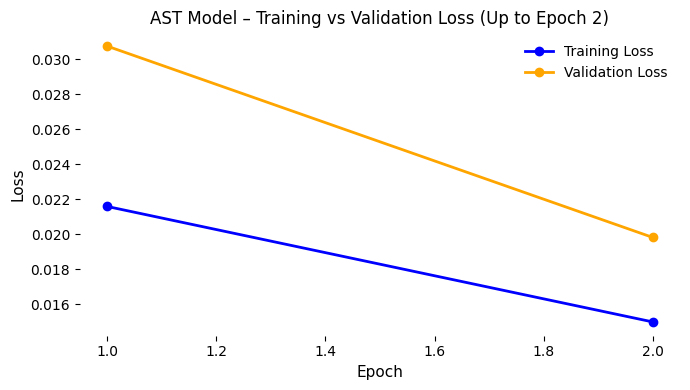

In [1]:
import matplotlib.pyplot as plt

# === AST fine-tuning data ===
epochs = [1, 2]
train_loss = [0.0216, 0.0150]
val_loss = [0.030764, 0.019830]

# === Create plot ===
plt.figure(figsize=(7, 4))

# Plot lines
plt.plot(epochs, train_loss, color='blue', marker='o', linewidth=2, label='Training Loss')
plt.plot(epochs, val_loss, color='orange', marker='o', linewidth=2, label='Validation Loss')

# Titles and labels
plt.title('AST Model – Training vs Validation Loss (Up to Epoch 2)', fontsize=12)
plt.xlabel('Epoch', fontsize=11)
plt.ylabel('Loss', fontsize=11)

# Make background plain white and remove boxes
plt.gca().set_facecolor('white')
for spine in plt.gca().spines.values():
    spine.set_visible(True)  # keep axes lines
plt.grid(False)              # no grid
plt.box(False)               # remove outer frame

# Legend
plt.legend(frameon=False, fontsize=10)

# Adjust layout and show
plt.tight_layout()
plt.show()


In [2]:
# ==== TEST-ONLY EVALUATION (PaSST) FOR ALREADY-CHUNKED TEST FILES ====
import os, json, glob, re
import numpy as np
import pandas as pd
import torch, torchaudio
from transformers import AutoFeatureExtractor, AutoModelForAudioClassification
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

# --------------------
# Config
# --------------------
CKPT_BASE = "D:\Thesis\Song\TrainClassification\passt-light-finetuned\checkpoint-7158"   # folder where you trained PaSST
TEST_DIR  = "D:\Thesis\Song\dataset\Test"              # contains Real_*.wav / Fake_*.wav (already chunked)
BATCH_SIZE = 48                         # increase/decrease based on VRAM/CPU
torch.set_num_threads(1)

# --------------------
# Helpers
# --------------------
def resolve_checkpoint_dir(base_dir="./passt-light-finetuned"):
    """Use best_model_checkpoint if present; else last checkpoint-*; else base_dir."""
    if not os.path.isdir(base_dir):
        raise RuntimeError(f"Checkpoint dir not found: {base_dir}")
    state_path = os.path.join(base_dir, "trainer_state.json")
    if os.path.isfile(state_path):
        try:
            with open(state_path, "r", encoding="utf-8") as f:
                state = json.load(f)
            best = state.get("best_model_checkpoint", None)
            if best and os.path.isdir(best):
                return best
        except Exception:
            pass
    ckpts = [p for p in glob.glob(os.path.join(base_dir, "checkpoint-*")) if os.path.isdir(p)]
    if ckpts:
        def step_num(p):
            m = re.search(r"checkpoint-(\d+)", p)
            return int(m.group(1)) if m else -1
        ckpts.sort(key=step_num)
        return ckpts[-1]
    return base_dir

def softmax_np(z):
    z = z - z.max(axis=1, keepdims=True)
    ez = np.exp(z)
    return ez / ez.sum(axis=1, keepdims=True)

def list_labeled_files(test_dir):
    files, labels = [], []
    for fname in sorted(os.listdir(test_dir)):
        if fname.lower().endswith(".wav"):
            label = 0 if fname.lower().startswith("real_") else 1
            files.append(os.path.join(test_dir, fname))
            labels.append(label)
    if not files:
        raise RuntimeError(f"No .wav files in {test_dir} (expected Real_*.wav / Fake_*.wav)")
    return files, np.array(labels, dtype=int)

# --------------------
# Load model + feature extractor
# --------------------
ckpt_dir = resolve_checkpoint_dir(CKPT_BASE)
print(f"Loading checkpoint from: {ckpt_dir}")

# Load feature extractor (prefer from checkpoint directory)
try:
    feature_extractor = AutoFeatureExtractor.from_pretrained(ckpt_dir)
except Exception:
    feature_extractor = AutoFeatureExtractor.from_pretrained("MIT/ast-finetuned-audioset-10-10-0.4593")

TARGET_SR = getattr(feature_extractor, "sampling_rate", 32000)  # AST uses 32k
model = AutoModelForAudioClassification.from_pretrained(ckpt_dir)
device = "cuda" if torch.cuda.is_available() else "cpu"
model.to(device)
model.eval()

# --------------------
# Collect test files
# --------------------
X, y_true = list_labeled_files(TEST_DIR)
print(f"Found {len(X)} test chunks.")

# --------------------
# Batched inference (no sliding windows)
# --------------------
logits_list = []
for i in range(0, len(X), BATCH_SIZE):
    batch_paths = X[i:i+BATCH_SIZE]
    waves = []
    for p in batch_paths:
        wav, sr = torchaudio.load(p)
        if wav.shape[0] > 1:
            wav = wav.mean(dim=0, keepdim=True)
        if sr != TARGET_SR:
            wav = torchaudio.functional.resample(wav, sr, TARGET_SR)
        waves.append(wav.squeeze(0).numpy())

    with torch.no_grad():
        feats = feature_extractor(
            waves,
            sampling_rate=TARGET_SR,
            return_tensors="pt",
            padding=True
        )
        feats = {k: v.to(device) for k, v in feats.items()}
        out = model(**feats).logits  # [B, 2]
        logits_list.append(out.cpu().numpy())

    print(f"Processed {min(i+BATCH_SIZE, len(X))}/{len(X)}")

logits = np.concatenate(logits_list, axis=0)  # [N, 2]
y_pred = logits.argmax(axis=-1)
probs  = softmax_np(logits)
p_fake = probs[:, 1]  # probability of class 1 (Fake)

# --------------------
# Reports + CSVs
# --------------------
target_names = ["Real (0)", "Fake (1)"]

rep_str  = classification_report(y_true, y_pred, target_names=target_names, digits=4)
rep_dict = classification_report(y_true, y_pred, target_names=target_names, output_dict=True)
rep_df   = pd.DataFrame(rep_dict).transpose()
print("\n=== Classification Report (Test) ===")
print(rep_str)

cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
cm_df = pd.DataFrame(cm, index=["True Real (0)", "True Fake (1)"],
                        columns=["Pred Real (0)", "Pred Fake (1)"])
print("\n=== Confusion Matrix (Test) ===")
print(cm_df)

try:
    auc = roc_auc_score(y_true, p_fake)
    print(f"\nAUC (Fake=positive): {auc:.4f}")
except ValueError:
    print("\nAUC could not be computed (need both classes present).")

per_file_df = pd.DataFrame({
    "Filename": [os.path.basename(p) for p in X],
    "TrueLabel": ["Real" if t == 0 else "Fake" for t in y_true],
    "PredLabel": ["Real" if p == 0 else "Fake" for p in y_pred],
    "Prob_Fake": p_fake
}).sort_values("Prob_Fake", ascending=False).reset_index(drop=True)

# Save to the training folder
os.makedirs(CKPT_BASE, exist_ok=True)
rep_df.to_csv(os.path.join(CKPT_BASE, "classification_report_test.csv"), index=True)
cm_df.to_csv(os.path.join(CKPT_BASE, "confusion_matrix_test.csv"), index=True)
per_file_df.to_csv(os.path.join(CKPT_BASE, "per_file_predictions.csv"), index=False)

with open(os.path.join(CKPT_BASE, "classification_report_test.txt"), "w", encoding="utf-8") as f:
    f.write(rep_str)

print("\nSaved:")
print(" -", os.path.join(CKPT_BASE, "classification_report_test.csv"))
print(" -", os.path.join(CKPT_BASE, "confusion_matrix_test.csv"))
print(" -", os.path.join(CKPT_BASE, "per_file_predictions.csv"))
print(" -", os.path.join(CKPT_BASE, "classification_report_test.txt"))


Loading checkpoint from: ./passt-light-finetuned\checkpoint-4772
Found 1718 test chunks.
Processed 48/1718
Processed 96/1718
Processed 144/1718
Processed 192/1718
Processed 240/1718
Processed 288/1718
Processed 336/1718
Processed 384/1718
Processed 432/1718
Processed 480/1718
Processed 528/1718
Processed 576/1718
Processed 624/1718
Processed 672/1718
Processed 720/1718
Processed 768/1718
Processed 816/1718
Processed 864/1718
Processed 912/1718
Processed 960/1718
Processed 1008/1718
Processed 1056/1718
Processed 1104/1718
Processed 1152/1718
Processed 1200/1718
Processed 1248/1718
Processed 1296/1718
Processed 1344/1718
Processed 1392/1718
Processed 1440/1718
Processed 1488/1718
Processed 1536/1718
Processed 1584/1718
Processed 1632/1718
Processed 1680/1718
Processed 1718/1718

=== Classification Report (Test) ===
              precision    recall  f1-score   support

    Real (0)     0.8893    1.0000    0.9414       916
    Fake (1)     1.0000    0.8579    0.9235       802

    accurac

Save Each 500 Steps

In [ ]:
# !pip install transformers torchaudio datasets accelerate evaluate

import os
import torch
import torchaudio
from torch.utils.data import Dataset
from transformers import AutoFeatureExtractor, AutoModelForAudioClassification, Trainer, TrainingArguments
import evaluate

# --------------------
# Paths
# --------------------
TRAIN_DIR = "D:\Thesis\Song\dataset\Train"
VAL_DIR   = "D:\Thesis\Song\dataset\Valid"
TEST_DIR  = "D:\Thesis\Song\dataset\Test"

# --------------------
# Load feature extractor & model
# --------------------
MODEL_ID = "MIT/ast-finetuned-audioset-10-10-0.4593"
feature_extractor = AutoFeatureExtractor.from_pretrained(MODEL_ID)
model = AutoModelForAudioClassification.from_pretrained(
    MODEL_ID,
    num_labels=2,
    ignore_mismatched_sizes=True,  # Ignore final layer size mismatch

)

TARGET_SR = feature_extractor.sampling_rate  # PaSST expects 32000 Hz

# --------------------
# Dataset
# --------------------
class PaSSTDataset(Dataset):
    def __init__(self, root_dir, feature_extractor, target_sr):
        self.files = []
        self.labels = []
        self.feature_extractor = feature_extractor
        self.target_sr = target_sr

        min_len = int(0.025 * target_sr)  # 25ms minimum window size

        for fname in sorted(os.listdir(root_dir)):
            if fname.lower().endswith(".wav"):
                path = os.path.join(root_dir, fname)
                label = 0 if fname.lower().startswith("real_") else 1

                # Load just to check lengthff
                waveform, sr = torchaudio.load(path)
                if waveform.shape[0] > 1:
                    waveform = waveform.mean(dim=0, keepdim=True)
                if sr != target_sr:
                    waveform = torchaudio.functional.resample(waveform, sr, target_sr)
                waveform = waveform.squeeze()

                # Keep only if long enough
                if waveform.shape[-1] >= min_len:
                    self.files.append(path)
                    self.labels.append(label)

        print(f"Loaded {len(self.files)} files from {root_dir} (dropped too-short ones)")

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        path = self.files[idx]
        label = self.labels[idx]
        waveform, sr = torchaudio.load(path)

        if waveform.shape[0] > 1:
            waveform = waveform.mean(dim=0, keepdim=True)
        if sr != self.target_sr:
            waveform = torchaudio.functional.resample(waveform, sr, self.target_sr)
        waveform = waveform.squeeze().numpy()

        inputs = self.feature_extractor(
            waveform,
            sampling_rate=self.target_sr,
            return_tensors="pt",
            padding=True
        )
        inputs = {k: v.squeeze(0) for k, v in inputs.items()}
        inputs["labels"] = torch.tensor(label, dtype=torch.long)
        return inputs


# --------------------
# Build datasets
# --------------------
train_dataset = PaSSTDataset(TRAIN_DIR, feature_extractor, TARGET_SR)
val_dataset   = PaSSTDataset(VAL_DIR,   feature_extractor, TARGET_SR)
test_dataset  = PaSSTDataset(TEST_DIR,  feature_extractor, TARGET_SR)

# --------------------
# Metrics
# --------------------
accuracy_metric = evaluate.load("accuracy")
f1_metric = evaluate.load("f1")
roc_metric = evaluate.load("roc_auc")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = logits.argmax(axis=-1)
    probs = torch.softmax(torch.tensor(logits), dim=-1)[:, 1].numpy()
    return {
        "accuracy": accuracy_metric.compute(predictions=preds, references=labels)["accuracy"],
        "f1_macro": f1_metric.compute(predictions=preds, references=labels, average="macro")["f1"],
        "auroc": roc_metric.compute(prediction_scores=probs, references=labels)["roc_auc"]
    }

# --------------------
# Training arguments
# --------------------
training_args = TrainingArguments(
    output_dir="./ast-light-finetuned",
    eval_strategy="steps",
    save_strategy="steps",
    eval_steps=500, 
    save_steps=500,
    load_best_model_at_end=True,
    metric_for_best_model="auroc",
    greater_is_better=True,
    learning_rate=3e-5,
    per_device_train_batch_size=6,
    per_device_eval_batch_size=4,
    num_train_epochs=3,
    weight_decay=0.01,
    logging_dir="./logs",
    logging_steps=100,
    fp16=torch.cuda.is_available(),
    push_to_hub=False,
    seed=42
)

# --------------------
# Trainer
# --------------------
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    tokenizer=feature_extractor,
    compute_metrics=compute_metrics
)

# --------------------
# Train
# --------------------
trainer.train()

# --------------------
# Evaluate on test set
# --------------------
test_metrics = trainer.evaluate(test_dataset)
print("\n=== Test set metrics ===")
for k, v in test_metrics.items():
    if k.startswith("eval_"):
        print(f"{k[5:]}: {v:.4f}")


Fetching 1 files:   0%|          | 0/1 [00:00<?, ?it/s]

Some weights of ASTForAudioClassification were not initialized from the model checkpoint at MIT/ast-finetuned-audioset-10-10-0.4593 and are newly initialized because the shapes did not match:
- classifier.dense.bias: found shape torch.Size([527]) in the checkpoint and torch.Size([2]) in the model instantiated
- classifier.dense.weight: found shape torch.Size([527, 768]) in the checkpoint and torch.Size([2, 768]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Loaded 14315 files from D:\Thesis\Song\dataset\Train (dropped too-short ones)
Loaded 1457 files from D:\Thesis\Song\dataset\Valid (dropped too-short ones)
Loaded 1718 files from D:\Thesis\Song\dataset\Test (dropped too-short ones)


C:\Users\j3n50\AppData\Local\Temp\ipykernel_18388\867683108.py:139: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Step,Training Loss,Validation Loss,Accuracy,F1 Macro,Auroc
500,0.099400,0.160256,0.969115,0.968851,0.997082
1000,0.040600,0.025727,0.995882,0.995861,0.999779
1500,0.024800,0.313584,0.949897,0.949138,0.996938
2000,0.043800,0.016580,0.995196,0.995168,0.999922
2500,0.013100,0.085005,0.988332,0.988255,0.999057
3000,0.010200,0.058522,0.986960,0.986898,0.999608
3500,0.011700,0.034192,0.993823,0.993790,0.999866
4000,0.000100,0.109318,0.984900,0.984799,0.999023
4500,0.000000,0.034181,0.995882,0.995861,0.999841


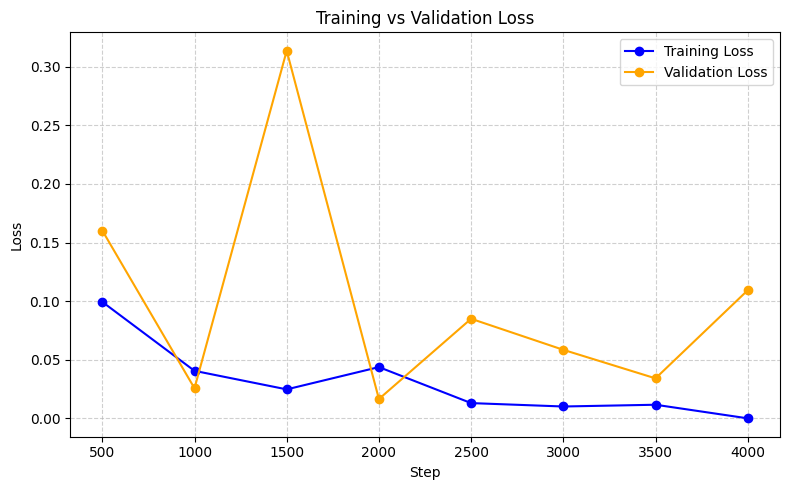

In [1]:
import matplotlib.pyplot as plt

# Data
steps = [500, 1000, 1500, 2000, 2500, 3000, 3500, 4000]
train_loss = [0.099400, 0.040600, 0.024800, 0.043800, 0.013100, 0.010200, 0.011700, 0.000100]
val_loss = [0.160256, 0.025727, 0.313584, 0.016580, 0.085005, 0.058522, 0.034192, 0.109318]

# Create plot
plt.figure(figsize=(8, 5))
plt.plot(steps, train_loss, color='blue', marker='o', label='Training Loss')
plt.plot(steps, val_loss, color='orange', marker='o', label='Validation Loss')

# Add labels and title
plt.title('Training vs Validation Loss')
plt.xlabel('Step')
plt.ylabel('Loss')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.tight_layout()

# Show plot
plt.show()


Second Epoch

In [2]:
# ==== TEST-ONLY EVALUATION (PaSST) FOR ALREADY-CHUNKED TEST FILES ====
import os, json, glob, re
import numpy as np
import pandas as pd
import torch, torchaudio
from transformers import AutoFeatureExtractor, AutoModelForAudioClassification
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

# --------------------
# Config
# --------------------
CKPT_BASE = r"D:\Thesis\Song\TrainClassification\ast-light-finetuned\checkpoint-3500"   # folder where you trained PaSST
TEST_DIR  = "D:\Thesis\Song\dataset\Test"              # contains Real_*.wav / Fake_*.wav (already chunked)
BATCH_SIZE = 48                         # increase/decrease based on VRAM/CPU
torch.set_num_threads(1)

# --------------------
# Helpers
# --------------------
def resolve_checkpoint_dir(base_dir="./passt-light-finetuned"):
    """Use best_model_checkpoint if present; else last checkpoint-*; else base_dir."""
    if not os.path.isdir(base_dir):
        raise RuntimeError(f"Checkpoint dir not found: {base_dir}")
    state_path = os.path.join(base_dir, "trainer_state.json")
    if os.path.isfile(state_path):
        try:
            with open(state_path, "r", encoding="utf-8") as f:
                state = json.load(f)
            best = state.get("best_model_checkpoint", None)
            if best and os.path.isdir(best):
                return best
        except Exception:
            pass
    ckpts = [p for p in glob.glob(os.path.join(base_dir, "checkpoint-*")) if os.path.isdir(p)]
    if ckpts:
        def step_num(p):
            m = re.search(r"checkpoint-(\d+)", p)
            return int(m.group(1)) if m else -1
        ckpts.sort(key=step_num)
        return ckpts[-1]
    return base_dir

def softmax_np(z):
    z = z - z.max(axis=1, keepdims=True)
    ez = np.exp(z)
    return ez / ez.sum(axis=1, keepdims=True)

def list_labeled_files(test_dir):
    files, labels = [], []
    for fname in sorted(os.listdir(test_dir)):
        if fname.lower().endswith(".wav"):
            label = 0 if fname.lower().startswith("real_") else 1
            files.append(os.path.join(test_dir, fname))
            labels.append(label)
    if not files:
        raise RuntimeError(f"No .wav files in {test_dir} (expected Real_*.wav / Fake_*.wav)")
    return files, np.array(labels, dtype=int)

# --------------------
# Load model + feature extractor
# --------------------
ckpt_dir = resolve_checkpoint_dir(CKPT_BASE)
print(f"Loading checkpoint from: {ckpt_dir}")

# Load feature extractor (prefer from checkpoint directory)
try:
    feature_extractor = AutoFeatureExtractor.from_pretrained(ckpt_dir)
except Exception:
    feature_extractor = AutoFeatureExtractor.from_pretrained("MIT/ast-finetuned-audioset-10-10-0.4593")

TARGET_SR = getattr(feature_extractor, "sampling_rate", 32000)  # AST uses 32k
model = AutoModelForAudioClassification.from_pretrained(ckpt_dir)
device = "cuda" if torch.cuda.is_available() else "cpu"
model.to(device)
model.eval()

# --------------------
# Collect test files
# --------------------
X, y_true = list_labeled_files(TEST_DIR)
print(f"Found {len(X)} test chunks.")

# --------------------
# Batched inference (no sliding windows)
# --------------------
logits_list = []
for i in range(0, len(X), BATCH_SIZE):
    batch_paths = X[i:i+BATCH_SIZE]
    waves = []
    for p in batch_paths:
        wav, sr = torchaudio.load(p)
        if wav.shape[0] > 1:
            wav = wav.mean(dim=0, keepdim=True)
        if sr != TARGET_SR:
            wav = torchaudio.functional.resample(wav, sr, TARGET_SR)
        waves.append(wav.squeeze(0).numpy())

    with torch.no_grad():
        feats = feature_extractor(
            waves,
            sampling_rate=TARGET_SR,
            return_tensors="pt",
            padding=True
        )
        feats = {k: v.to(device) for k, v in feats.items()}
        out = model(**feats).logits  # [B, 2]
        logits_list.append(out.cpu().numpy())

    print(f"Processed {min(i+BATCH_SIZE, len(X))}/{len(X)}")

logits = np.concatenate(logits_list, axis=0)  # [N, 2]
y_pred = logits.argmax(axis=-1)
probs  = softmax_np(logits)
p_fake = probs[:, 1]  # probability of class 1 (Fake)

# --------------------
# Reports + CSVs
# --------------------
target_names = ["Real (0)", "Fake (1)"]

rep_str  = classification_report(y_true, y_pred, target_names=target_names, digits=4)
rep_dict = classification_report(y_true, y_pred, target_names=target_names, output_dict=True)
rep_df   = pd.DataFrame(rep_dict).transpose()
print("\n=== Classification Report (Test) ===")
print(rep_str)

cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
cm_df = pd.DataFrame(cm, index=["True Real (0)", "True Fake (1)"],
                        columns=["Pred Real (0)", "Pred Fake (1)"])
print("\n=== Confusion Matrix (Test) ===")
print(cm_df)

try:
    auc = roc_auc_score(y_true, p_fake)
    print(f"\nAUC (Fake=positive): {auc:.4f}")
except ValueError:
    print("\nAUC could not be computed (need both classes present).")

per_file_df = pd.DataFrame({
    "Filename": [os.path.basename(p) for p in X],
    "TrueLabel": ["Real" if t == 0 else "Fake" for t in y_true],
    "PredLabel": ["Real" if p == 0 else "Fake" for p in y_pred],
    "Prob_Fake": p_fake
}).sort_values("Prob_Fake", ascending=False).reset_index(drop=True)

# Save to the training folder
os.makedirs(CKPT_BASE, exist_ok=True)
rep_df.to_csv(os.path.join(CKPT_BASE, "classification_report_test.csv"), index=True)
cm_df.to_csv(os.path.join(CKPT_BASE, "confusion_matrix_test.csv"), index=True)
per_file_df.to_csv(os.path.join(CKPT_BASE, "per_file_predictions.csv"), index=False)

with open(os.path.join(CKPT_BASE, "classification_report_test.txt"), "w", encoding="utf-8") as f:
    f.write(rep_str)

print("\nSaved:")
print(" -", os.path.join(CKPT_BASE, "classification_report_test.csv"))
print(" -", os.path.join(CKPT_BASE, "confusion_matrix_test.csv"))
print(" -", os.path.join(CKPT_BASE, "per_file_predictions.csv"))
print(" -", os.path.join(CKPT_BASE, "classification_report_test.txt"))


Loading checkpoint from: ./ast-light-finetuned\checkpoint-2000
Found 1718 test chunks.
Processed 48/1718
Processed 96/1718
Processed 144/1718
Processed 192/1718
Processed 240/1718
Processed 288/1718
Processed 336/1718
Processed 384/1718
Processed 432/1718
Processed 480/1718
Processed 528/1718
Processed 576/1718
Processed 624/1718
Processed 672/1718
Processed 720/1718
Processed 768/1718
Processed 816/1718
Processed 864/1718
Processed 912/1718
Processed 960/1718
Processed 1008/1718
Processed 1056/1718
Processed 1104/1718
Processed 1152/1718
Processed 1200/1718
Processed 1248/1718
Processed 1296/1718
Processed 1344/1718
Processed 1392/1718
Processed 1440/1718
Processed 1488/1718
Processed 1536/1718
Processed 1584/1718
Processed 1632/1718
Processed 1680/1718
Processed 1718/1718

=== Classification Report (Test) ===
              precision    recall  f1-score   support

    Real (0)     0.8455    0.9978    0.9154       916
    Fake (1)     0.9969    0.7918    0.8826       802

    accuracy 